In [2]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
iris=load_iris()
X=iris.data[:,(2,3)]
y=(iris.target==0).astype(int)

In [3]:
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [4]:
per_clf = Perceptron()
per_clf.fit(X,y)
y_pred = per_clf.predict([[2,0.5]])

The hyperbolic tangent function tanh(z) = 2σ(2z) – 1

The Rectified Linear Unit function: ReLU(z) = max(0, z)

Regression MLPs

The Huber loss is quadratic when the error is smaller than a thres‐
hold δ (typically 1), but linear when the error is larger than δ. This
makes it less sensitive to outliers than the mean squared error, and
it is often more precise and converges faster than the mean abso‐
lute error

In [5]:
import tensorflow as tf
from tensorflow import keras 
tf.__version__

'2.21.0'

In [6]:
keras.__version__

'3.14.0'

Building a Image Classifier using the Sequential API

In [7]:
fashion_mnist = keras.datasets.fashion_mnist 
(X_train_full,y_train_full),(X_test,y_test) = fashion_mnist.load_data()

In [8]:
X_train_full.shape

(60000, 28, 28)

In [9]:
X_test.dtype

dtype('uint8')

In [10]:
X_valid,X_train = X_train_full[:5000]/255.0, X_train_full[5000:]/255.0
y_valid,y_train= y_train_full[:5000],y_train_full[5000:]

In [11]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28]))
model.add(keras.layers.Dense(300,activation='relu'))
model.add(keras.layers.Dense(100,activation='relu'))
model.add(keras.layers.Dense(10,activation='softmax'))


c:\Users\91911\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


OR

In [12]:
model = keras.models.Sequential(
    [
        keras.layers.Flatten(input_shape=[28,28]),
        keras.layers.Dense(300,activation='relu'),
        keras.layers.Dense(100,activation='relu'),
        keras.layers.Dense(10,activation='softmax')
    ]
)

In [13]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
hidden1 = model.layers[1]
weights,biases = hidden1.get_weights()


In [15]:
weights.shape, biases.shape

((784, 300), (300,))

In [16]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer = 'sgd',
              metrics=['accuracy'])

Training and Evaluating the model

In [17]:
history = model.fit(X_train,y_train,epochs=10,validation_data=(X_valid,y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7705 - loss: 0.7051 - val_accuracy: 0.8350 - val_loss: 0.4977
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8303 - loss: 0.4839 - val_accuracy: 0.8520 - val_loss: 0.4404
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8452 - loss: 0.4404 - val_accuracy: 0.8576 - val_loss: 0.4218
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8546 - loss: 0.4146 - val_accuracy: 0.8482 - val_loss: 0.4362
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8610 - loss: 0.3961 - val_accuracy: 0.8512 - val_loss: 0.4198
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8673 - loss: 0.3803 - val_accuracy: 0.8678 - val_loss: 0.3861
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8703 - loss: 0.3680 - val_accuracy: 0.8732 - val_loss: 0.3592
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8735 - loss: 0.3551

In [18]:
tf.config.list_physical_devices('GPU')

[]

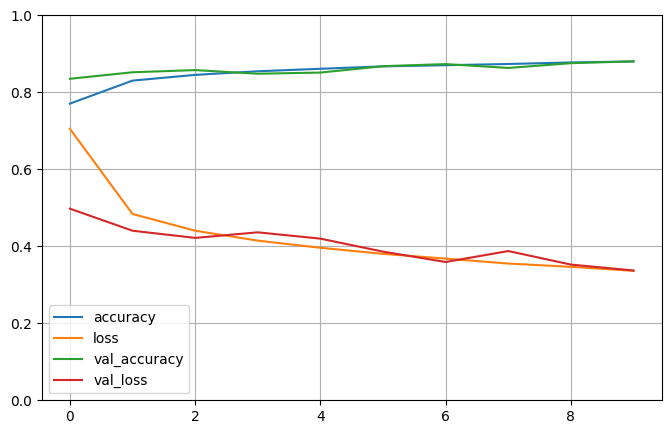

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()


In [20]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8366 - loss: 64.0592


[64.05923461914062, 0.8366000056266785]

Using the Model to make Predictions

In [21]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [22]:
y_pred = np.argmax(y_proba,axis=1)
y_pred

array([9, 2, 1])

In [23]:
y_test[:3]

array([9, 2, 1], dtype=uint8)

Building a Regression MLP Using the Sequential API

In [24]:
from sklearn.datasets import fetch_california_housing 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()

X = housing.data
y = housing.target

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,y
)

X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

In [25]:
model = keras.Sequential([
    keras.layers.Dense(30,activation='relu',input_shape=X_train.shape[1:]),
    keras.layers.Dense(1)
])

model.compile(loss='mean_squared_error',optimizer='sgd')
history = model.fit(X_train, y_train, epochs=10,
                    validation_data = (X_valid,y_valid))

mse_test = model.evaluate(X_test,y_test)
X_new = X[:3]
y_pred = model.predict(X_new)

Epoch 1/10


c:\Users\91911\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - val_loss: nan
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: nan - val_loss: nan
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - val_loss: nan
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - val_loss: nan
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - val_loss: nan
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: nan
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


Building Complex Models Using the Functional API

In [26]:
input = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(30,activation='relu')(input)
hidden2 = keras.layers.Dense(30,activation='relu')(hidden1)
concat = keras.layers.Concatenate()([input,hidden2])
output  = keras.layers.Dense(1)(concat)
model = keras.models.Model(inputs=[input],outputs=[output])

In [27]:
input_A = keras.layers.Input(shape=[5])
input_B = keras.layers.Input(shape=[6])
hidden1 = keras.layers.Dense(30,activation='relu')(input_B)
hidden2 = keras.layers.Dense(30,activation='relu')(hidden1)
concat = keras.layers.concatenate([input_A,hidden2])
output = keras.layers.Dense(1)(concat)
model = keras.models.Model(inputs=[input_A,input_B], outputs=[output])

In [28]:
model.compile(loss = 'mse' , optimizer='sgd')
X_train_A, X_train_B = X_train[:,:5], X_train[:,2:]
X_valid_A, X_valid_B = X_valid[:,:5], X_valid[:,2:]
X_test_A, X_test_B = X_test[:,:5], X_test[:,2:]
X_new_A, X_new_B = X_test_A[:3], X_test_B[:3]

history = model.fit((X_train_A,X_train_B),y_train, epochs=10,
                    validation_data=((X_valid_A, X_valid_B),y_valid))
mse = model.evaluate((X_test_A,X_test_B), y_test)
y_pred = model.predict((X_new_A,X_new_B))

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: nan - val_loss: nan
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - val_loss: nan
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - val_loss: nan
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - val_loss: nan
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: nan - val_loss: nan
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - val_loss: nan
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: nan - val_loss: nan
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - val_loss: nan
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: nan
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


In [29]:
input_A = keras.layers.Input(shape=[5])
input_B = keras.layers.Input(shape=[6])
hidden1 = keras.layers.Dense(30,activation='relu')(input_B)
hidden2 = keras.layers.Dense(30,activation='relu')(hidden1)
concat = keras.layers.concatenate([input_A,hidden2])
output = keras.layers.Dense(1)(concat)
aux_output = keras.layers.Dense(1)(hidden2)
model = keras.models.Model(inputs=[input_A,input_B], outputs=[output,aux_output])

In [30]:
model.compile(loss=['mse','mse'],loss_weights=[0.9,0.1],optimizer='sgd')

In [31]:
history = model.fit(
    [X_train_A,X_train_B],[y_train,y_train],epochs=10,
    validation_data=([X_valid_A,X_valid_B],[y_valid,y_valid])
)

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan - val_dense_16_loss: nan - val_dense_17_loss: nan - val_loss: nan
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan - val_dense_16_loss: nan - val_dense_17_loss: nan - val_loss: nan
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan - val_dense_16_loss: nan - val_dense_17_loss: nan - val_loss: nan
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan - val_dense_16_loss: nan - val_dense_17_loss: nan - val_loss: nan
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan - val_dense_16_loss: nan - val_dense_17_loss: nan - val_loss: nan
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan - val_dense_16_loss: nan - val_den

In [32]:
total_loss, main_loss, aux_loss = model.evaluate([X_test_A,X_test_B],[y_test,y_test])

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan


In [33]:
y_pred_main, y_pred_aux = model.predict([X_new_A,X_new_B])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


Building Dynamic Models Using the Subclassing API

In [34]:
class WideAndDeepModel(keras.models.Model):
    def __init__(self, units=30, activation="relu", **kwargs):
        super().__init__(**kwargs)
        
        self.hidden1 = keras.layers.Dense(units, activation=activation)
        self.hidden2 = keras.layers.Dense(units, activation=activation)
        
        self.concat = keras.layers.Concatenate()   
        
        self.main_output = keras.layers.Dense(1)
        self.aux_output = keras.layers.Dense(1)

    def call(self, inputs):
        input_A, input_B = inputs
        
        hidden1 = self.hidden1(input_B)
        hidden2 = self.hidden2(hidden1)
        
        concat = self.concat([input_A, hidden2])  
        
        main_output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        
        return main_output, aux_output

In [35]:
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 30)        │        210 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 30)        │        930 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 35)        │          0 │ input_layer_6[0]… │
│ (Concatenate)       │                   │            │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 1)         │         36 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 1)         │         31 │ dense_15[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,209 (4.73 KB)

 Trainable params: 1,207 (4.71 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Saving and Restoring a Model

In [36]:
model.save('my_keras_model.h5')

Loading

Using CallBacks<br> saving the model at checkpoints useful when training the model takes long time

The fit() method accepts a callbacks argument that lets you specify a list of objects
that Keras will call during training at the start and end of training, at the start and end
of each epoch and even before and after processing each batch. For example, the ModelCheckpoint callback saves checkpoints of your model at regular intervals during
training, by default at the end of each epoch:


In [37]:
model.compile(loss=['mse','mse'],optimizer='sgd')

In [38]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("my_keras_model.h5")
history = model.fit((X_train_A,X_train_B),(y_train,y_train),epochs=10,callbacks=[checkpoint_cb])

Epoch 1/10
358/363 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan

363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan
Epoch 2/10
343/363 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan

363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan
Epoch 3/10
362/363 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan

363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan
Epoch 4/10
350/363 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan

363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan
Epoch 5/10
360/363 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan

...

363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan
Epoch 7/10
360/363 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan

363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan
Epoch 8/10
342/363 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan

363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan
Epoch 9/10
359/363 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan

363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan

363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan


if you use a validation set during training, you can set
save_best_only=True when creating the ModelCheckpoint. In this case, it will only
save your model when its performance on the validation set is the best so far. This
way, you do not need to worry about training for too long and overfitting the training
set: simply restore the last model saved after training, and this will be the best model
on the validation set. This is a simple way to implement early stopping

Visualization Using TensorBoard

In [57]:
import os
import time
root_logdir = os.path.join(os.curdir,"my_logs")

def get_run_logdir():
    run_id = time.strftime("run_%Y_%m_%d_%H_%M_%S")
    return os.path.join(root_logdir,run_id)

In [58]:
model = keras.Sequential([
    keras.layers.Dense(30,activation = 'relu',input_shape = (X_train.shape[1],)),
    keras.layers.Dense(1)
])

In [59]:
run_logdir = get_run_logdir()

model.compile(loss='mse',optimizer='sgd')
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)
history =model.fit(X_train,y_train,validation_data=(X_valid,y_valid),
          epochs=10,callbacks=[tensorboard_cb])

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - val_loss: nan
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - val_loss: nan
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: nan - val_loss: nan
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: nan - val_loss: nan
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: nan - val_loss: nan
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: nan - val_loss: nan
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: nan - val_loss: nan
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: nan - val_loss: nan


Fine-Tuning Neural Network Hyperparameter

In [83]:
def build_model(n_hidden=1, n_neurons=30, learning_rate=3e-3,input_shape=(8,)):
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=input_shape))
    options={}
    for layers in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation='relu', **options))
    model.add(keras.layers.Dense(1,**options))
    optimizer = keras.optimizers.SGD(learning_rate)
    model.compile(loss='mse',optimizer=optimizer)
    return model

In [84]:
from scikeras.wrappers import KerasRegressor

keras_reg = KerasRegressor(model=build_model)

In [85]:
keras_reg.fit(X_train, y_train, epochs=10,
 validation_data=(X_valid, y_valid),
 callbacks=[keras.callbacks.EarlyStopping(patience=10)])
mse_test = keras_reg.score(X_test, y_test)
y_pred = keras_reg.predict(X_new)

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: inf - val_loss: inf
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: inf - val_loss: 25552949224429491227372471862689792.0000
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5812126008564781819890838433431552.0000 - val_loss: 323560368725206728616317303128064.0000
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 73595240357615871373234306809856.0000 - val_loss: 4097040233498876259703126491136.0000
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 931890267738333900888594186240.0000 - val_loss: 51878270074903400811484676096.0000
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11799945955348145085278584832.0000 - val_loss: 656901174037743550379065344.0000
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 149415315806486137225084928.0000 - val_loss: 8317937815348339210715136.0000
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1891953268316684666535936.

In [90]:
from scipy.stats import reciprocal
from sklearn.model_selection import RandomizedSearchCV

param_distribs = {
    'model__n_hidden':[0,1,2,3],
    'model__n_neurons':np.arange(1,100),
    'model__learning_rate':reciprocal(3e-4,3e-2)
}

rnd_search_cv = RandomizedSearchCV(keras_reg,param_distribs,n_iter=10,cv=3)
rnd_search_cv.fit(X_train,y_train,epochs=10,
                  validation_data=(X_valid,y_valid),
                  callbacks=[keras.callbacks.EarlyStopping(patience=10)])

Epoch 1/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 2/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - val_loss: nan
Epoch 3/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 4/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - val_loss: nan
Epoch 5/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: nan - val_loss: nan
Epoch 6/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 7/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: nan - val_loss: nan
Epoch 8/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - val_loss: nan
Epoch 9/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan
Epoch 10/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Epoch 1/10


c:\Users\91911\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\91911\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\91911\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 485, in __call__
    return estimator.score(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\91911\AppData\Local\Programs\Python\Python313\Lib\site-packages\scikeras\wrappers.py", line 1127, in score
    return self.scorer(y, y_pred, sample_weight=sample_weight, **score_args)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\91911\App

242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - val_loss: nan
Epoch 2/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: nan - val_loss: nan
Epoch 3/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - val_loss: nan
Epoch 4/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - val_loss: nan
Epoch 5/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 6/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 7/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: nan - val_loss: nan
Epoch 8/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 9/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - val_loss: nan
Epoch 10/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - val_loss: nan
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 926us/step
Epoch 1/10


c:\Users\91911\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\91911\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\91911\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 485, in __call__
    return estimator.score(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\91911\AppData\Local\Programs\Python\Python313\Lib\site-packages\scikeras\wrappers.py", line 1127, in score
    return self.scorer(y, y_pred, sample_weight=sample_weight, **score_args)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\91911\App

242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 2/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - val_loss: nan
Epoch 3/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - val_loss: nan
Epoch 4/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 5/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - val_loss: nan
Epoch 6/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: nan - val_loss: nan
Epoch 7/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: nan - val_loss: nan
Epoch 8/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - val_loss: nan
Epoch 9/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan
Epoch 10/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - val_loss: nan
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Epoch 1/10
 67/242 ━━━━━━━━━━━━━━━━━━━━ 0s 771us/step - loss: nan         

...

c:\Users\91911\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\91911\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\91911\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 485, in __call__
    return estimator.score(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\91911\AppData\Local\Programs\Python\Python313\Lib\site-packages\scikeras\wrappers.py", line 1127, in score
    return self.scorer(y, y_pred, sample_weight=sample_weight, **score_args)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\91911\App

242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 2/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - val_loss: nan
Epoch 3/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: nan - val_loss: nan
Epoch 4/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: nan - val_loss: nan
Epoch 5/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: nan - val_loss: nan
Epoch 6/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: nan - val_loss: nan
Epoch 7/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - val_loss: nan
Epoch 8/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: nan - val_loss: nan
Epoch 9/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - val_loss: nan
Epoch 10/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 541us/step
Epoch 1/10
  1/363 ━━━━━━━━━━━━━━━━━━━━ 45s 127ms/step - loss: 1875127.1250

c:\Users\91911\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\91911\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\91911\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 485, in __call__
    return estimator.score(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\91911\AppData\Local\Programs\Python\Python313\Lib\site-packages\scikeras\wrappers.py", line 1127, in score
    return self.scorer(y, y_pred, sample_weight=sample_weight, **score_args)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\91911\App

363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: nan - val_loss: nan
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KerasRegresso...se epochs=1 )
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': <scipy.stats....001ED4B072780>, 'model__n_hidden': [0, 1, ...], 'model__n_neurons': array([ 1, 2..., 97, 98, 99])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used h

In [91]:
rnd_search_cv.best_params_

{'model__learning_rate': np.float64(0.005482658766951394),
 'model__n_hidden': 0,
 'model__n_neurons': np.int64(60)}

In [92]:
rnd_search_cv.best_score_

np.float64(nan)

Number of Hidden Layers